In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

import joblib

In [150]:
df=pd.read_csv("/content/heart.csv")

In [109]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [110]:
df.shape

(302, 14)

In [111]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [112]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [113]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [114]:
df.duplicated().sum()

np.int64(0)

In [115]:
df.drop_duplicates(inplace=True)

In [116]:
df.shape

(302, 14)

In [117]:
df.describe ()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


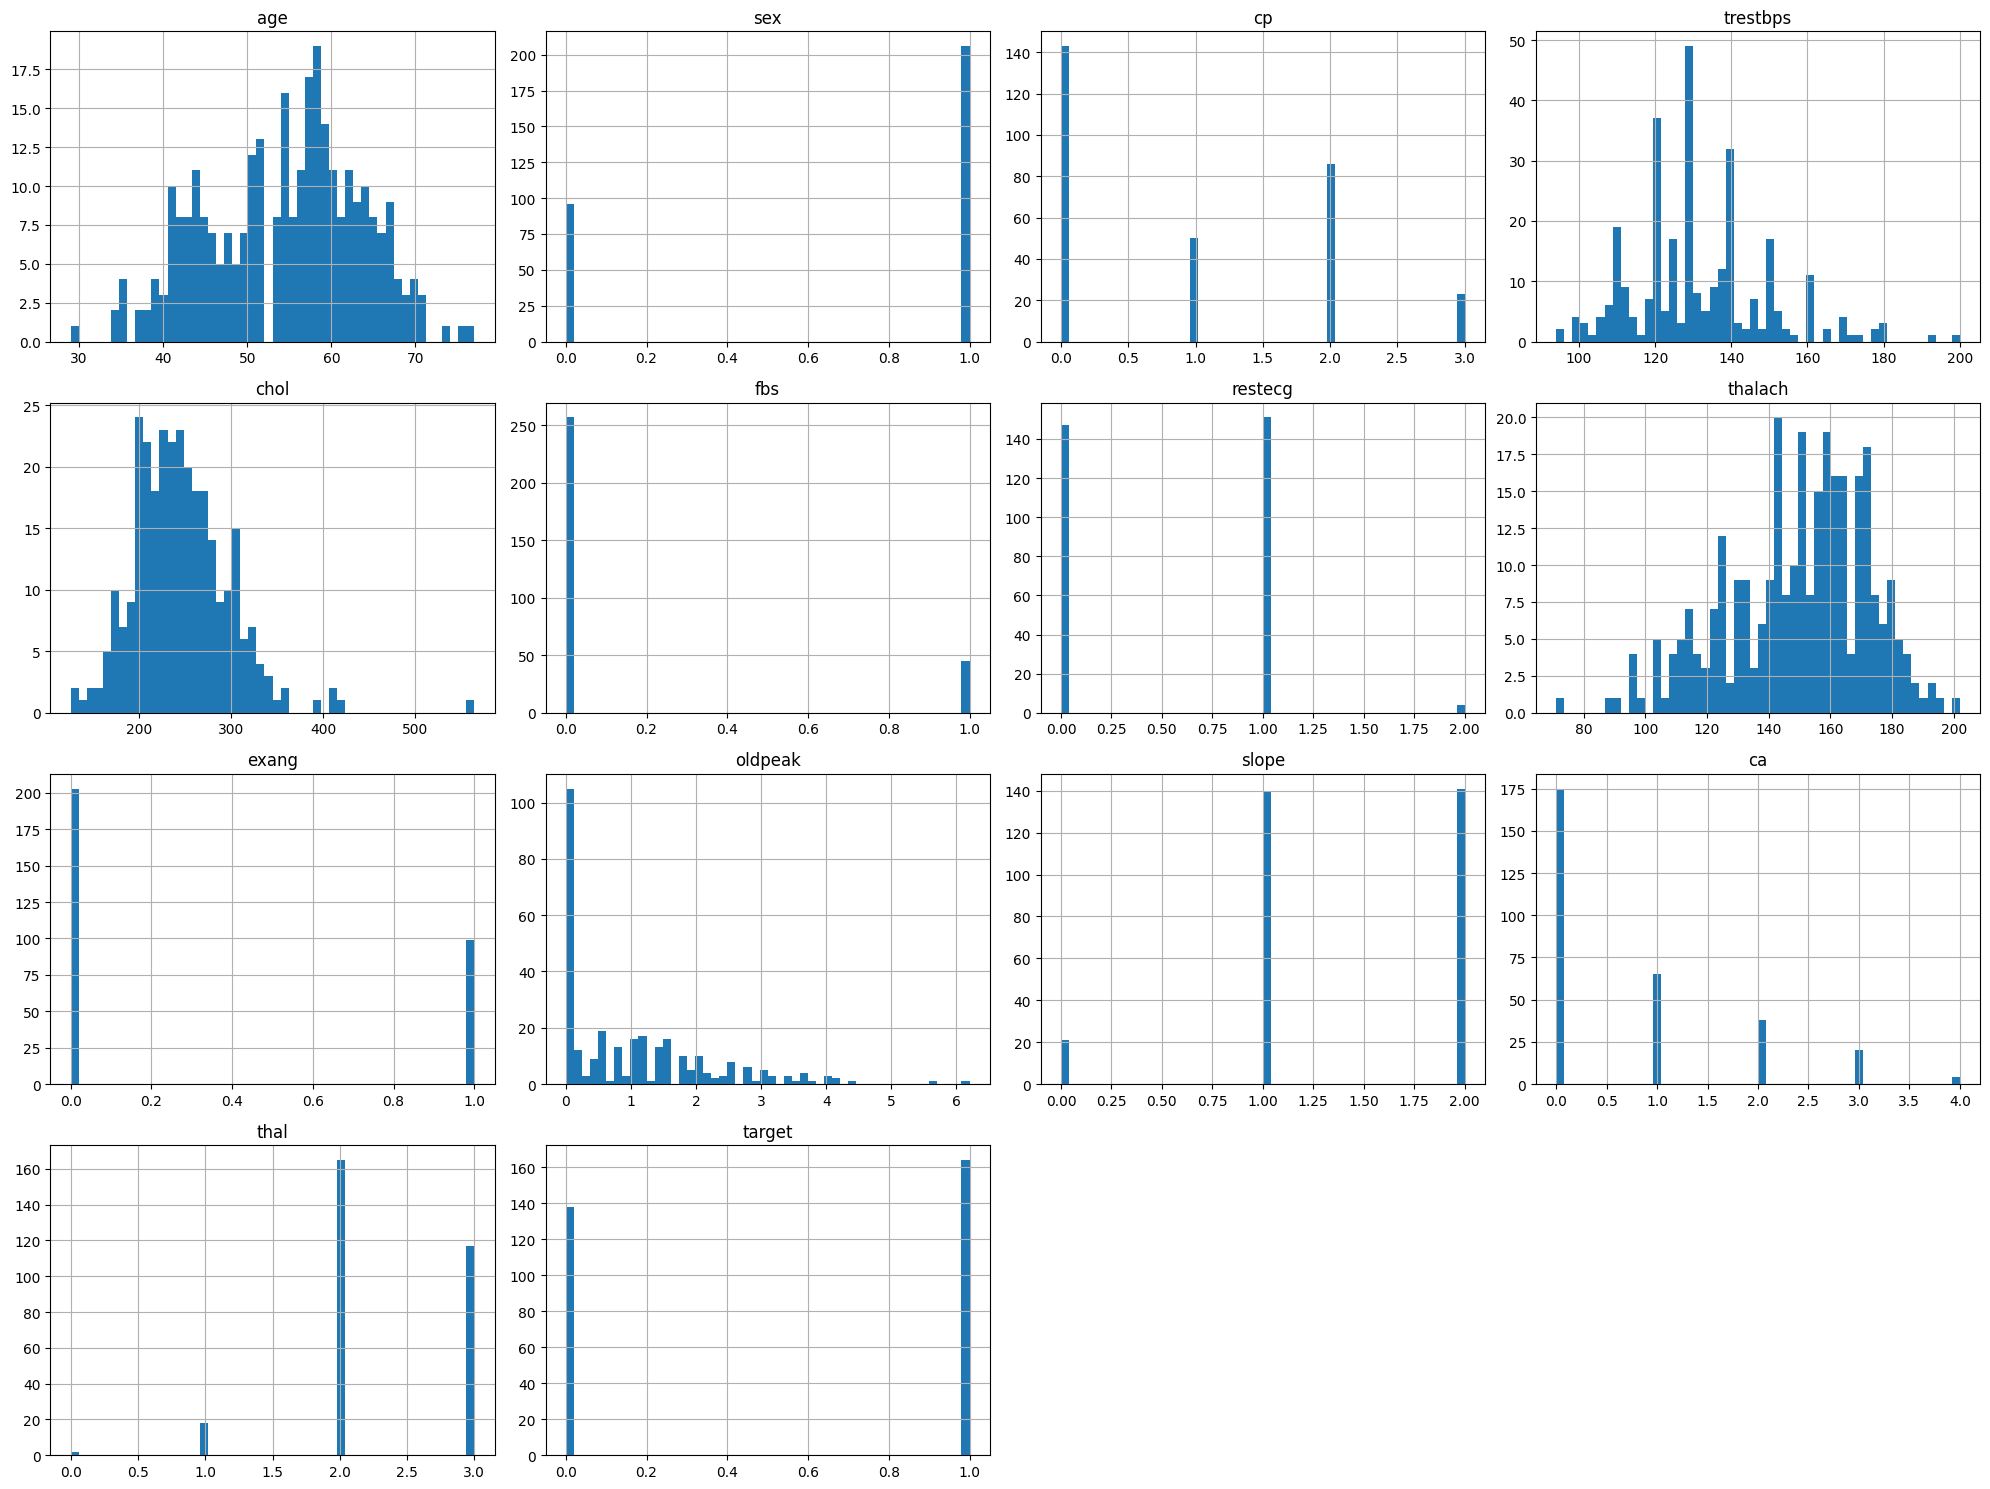

In [118]:
df.hist(bins=50, figsize=(20,15))
plt.tight_layout()
plt.show()

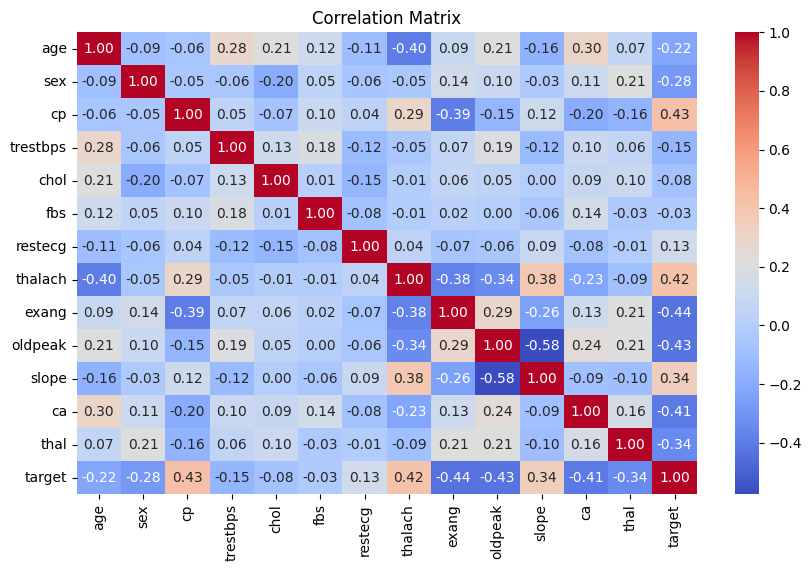

In [119]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True ,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

note

correlation matrix confirms that cp, thalach, exang, and oldpeak are the primary linear drivers of the target variable


Features such as fbs and chol show negligible linear correlation (|r| < 0.1)

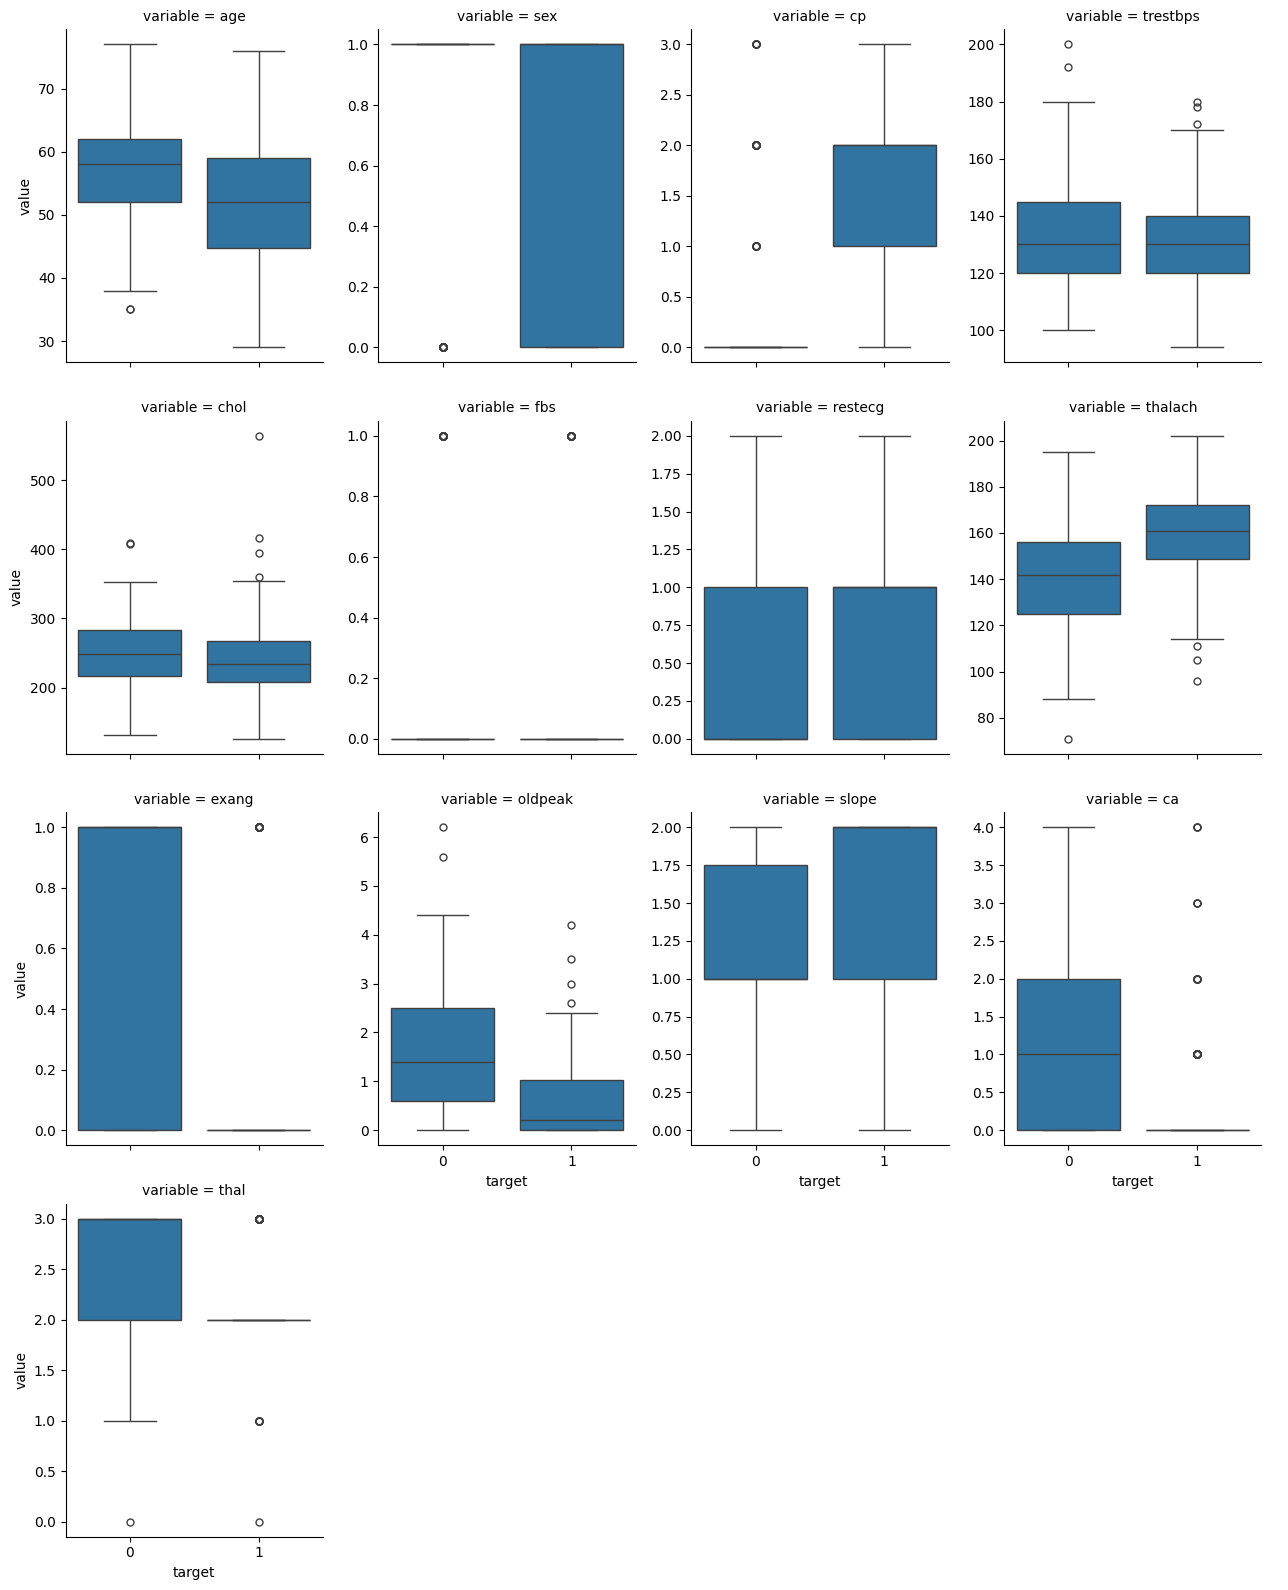

In [120]:
sns.catplot(x='target', y='value', col='variable', data=df.melt(id_vars='target'), kind='box', col_wrap=4, height=4, aspect=0.8, sharey=False)
plt.show()

In [121]:
corr = df.corr()['target'].sort_values(ascending=False)
print(corr)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64


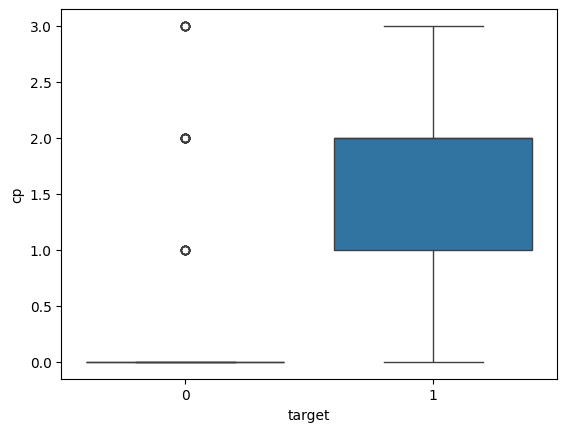

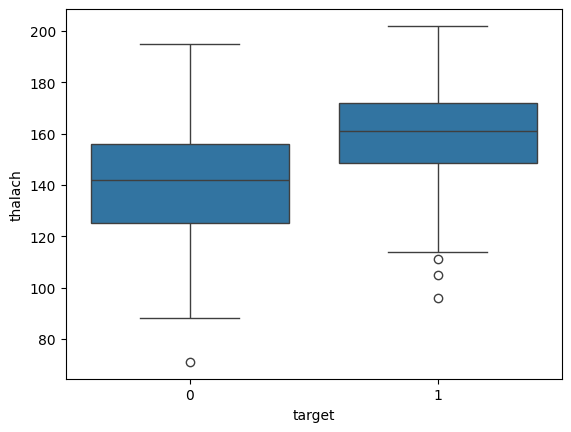

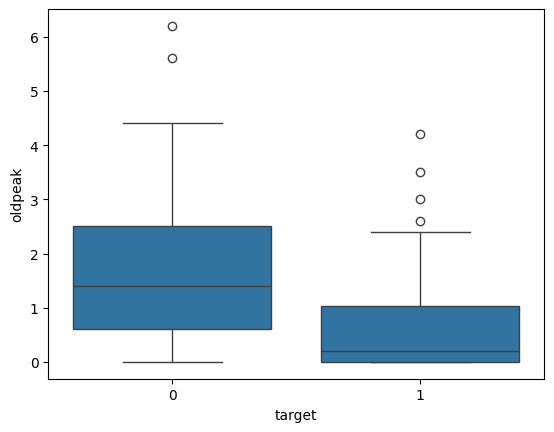

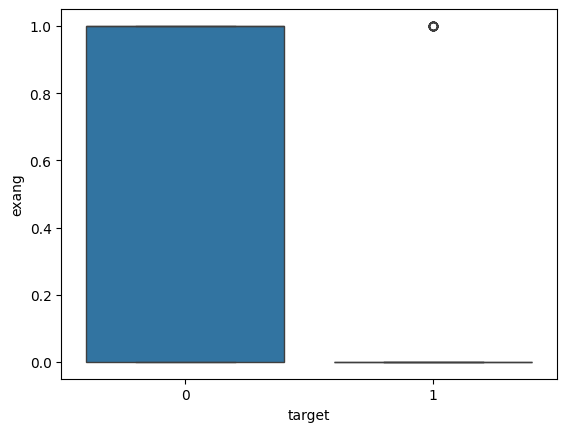

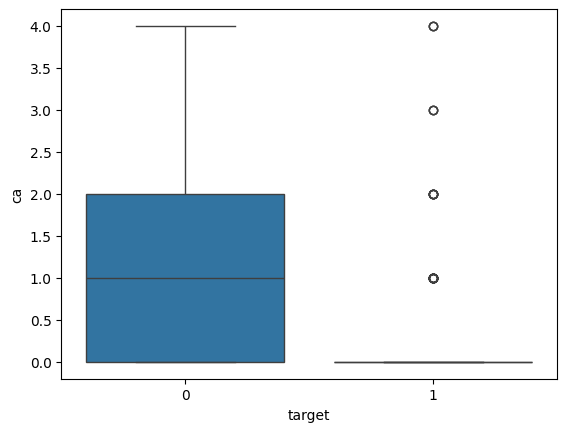

In [122]:
for col in ['cp','thalach','oldpeak','exang','ca']:
    sns.boxplot(x='target', y=col, data=df)
    plt.show()

geeting impotant features according to models

In [208]:
df_final = pd.get_dummies(df, columns=['cp', 'thal'], drop_first=True)

X = df_final.drop('target', axis=1)
y = df_final['target']

In [222]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [167]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

In [165]:
# GETTING TEH METUAL INFORMATION
mi_scores = mutual_info_classif(X_train,y_train,random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns)

In [168]:
# Get XGBoost Importance (Non-Linear Tree)
xgb = XGBClassifier(max_depth=3, random_state=42)
xgb.fit(X_train, y_train)
xgb_series = pd.Series(xgb.feature_importances_, index=X.columns)

In [169]:
#  Get Logistic Regression Coefficients (Linear - absolute values)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_series = pd.Series(np.abs(lr.coef_[0]), index=X.columns)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [170]:
#  Create Consensus Table
consensus = pd.DataFrame({
    'Mutual_Info': mi_series,
    'XGB_Tree': xgb_series,
    'Logistic_Linear': lr_series
})

consensus_norm = (consensus - consensus.min()) / (consensus.max() - consensus.min())
consensus_norm['Global_Score'] = consensus_norm.mean(axis=1)

print(consensus_norm.sort_values(by='Global_Score', ascending=False))

          Mutual_Info  XGB_Tree  Logistic_Linear  Global_Score
thal_2       1.000000  1.000000         0.535664      0.845221
exang        0.803849  0.525260         0.498227      0.609112
cp_2         0.483265  0.234176         1.000000      0.572480
cp_3              NaN  0.090489         0.814235      0.452362
thal_3       0.805115  0.106314         0.197604      0.369678
sex          0.339038  0.087757         0.656805      0.361200
ca           0.316207  0.216423         0.416294      0.316308
oldpeak      0.583430  0.102164         0.232893      0.306162
thal_1            NaN  0.051381         0.343743      0.197562
cp_1         0.000000  0.025198         0.481813      0.169004
slope             NaN  0.073145         0.262048      0.167597
restecg           NaN  0.085722         0.190578      0.138150
thalach      0.336830  0.058190         0.006504      0.133841
fbs               NaN  0.000000         0.061989      0.030994
age               NaN  0.055141         0.000674      0

final model training

In [210]:
final_features = ['thal_2', 'ca', 'exang', 'oldpeak', 'cp_2', 'thalach', 'sex', 'thal_3', 'cp_1']

X_train = X_train[final_features]
X_test = X_test[final_features]

In [211]:
print(X_train.shape)
print(y_train.shape)

(820, 9)
(820,)


In [212]:
tuned_rf = RandomForestClassifier(
    criterion='gini',
    max_depth=7,
    min_samples_split=5,
    class_weight='balanced',
    n_estimators=100,
    random_state=42
)

prod_pipeline = Pipeline([
    ('model', tuned_rf)
])

In [185]:
probs_train = cross_val_predict(
    prod_pipeline, X_train, y_train, cv=5, method='predict_proba'
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, probs_train)

target_recall = 0.95
idx = np.argmin(np.abs(recalls - target_recall))
best_threshold = thresholds[idx]

print("Best Threshold:", best_threshold)

Best Threshold: 0.4900768002057253


In [213]:
prod_pipeline.fit(X_train, y_train)

Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=7,
                                        min_samples_split=5,
                                        random_state=42))])

In [214]:
thresholds_to_try = [0.3, 0.35, 0.4, 0.45, 0.5]

for t in thresholds_to_try:
    y_pred = predict_with_threshold(probs_test, t)

    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.85      0.92       100
           1       0.88      1.00      0.93       105

    accuracy                           0.93       205
   macro avg       0.94      0.93      0.93       205
weighted avg       0.94      0.93      0.93       205


Threshold: 0.35
              precision    recall  f1-score   support

           0       1.00      0.85      0.92       100
           1       0.88      1.00      0.93       105

    accuracy                           0.93       205
   macro avg       0.94      0.93      0.93       205
weighted avg       0.94      0.93      0.93       205


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       100
           1       0.89      0.98      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93  

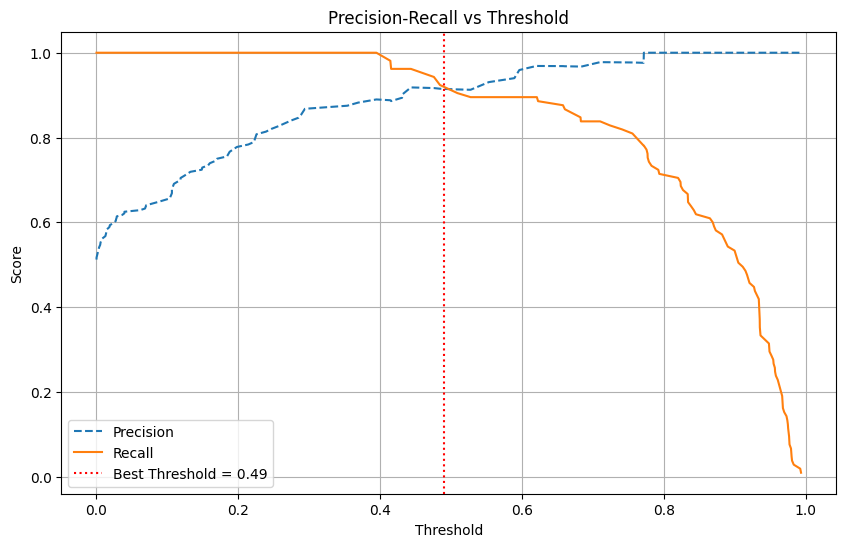

In [215]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, probs_test)

plt.figure(figsize=(10,6))

plt.plot(thresholds, precisions[:-1], label="Precision", linestyle='--')
plt.plot(thresholds, recalls[:-1], label="Recall")

plt.axvline(best_threshold, color='red', linestyle=':', label=f"Best Threshold = {best_threshold:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [216]:
FINAL_THRESHOLD = 0.40

y_pred_test = (probs_test >= FINAL_THRESHOLD).astype(int)

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.98      0.87      0.92       100
           1       0.89      0.98      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



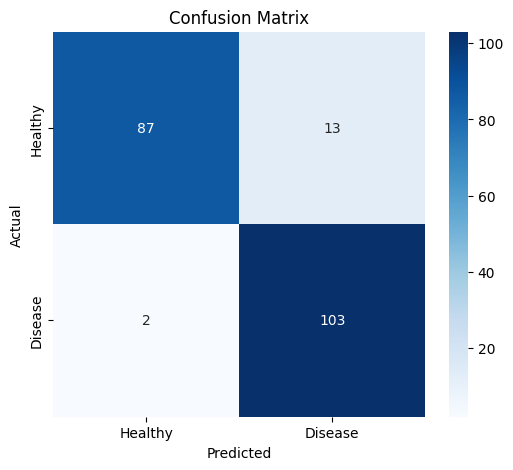

In [217]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Disease'],
            yticklabels=['Healthy', 'Disease'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [218]:
prod_pipeline.fit(X_train, y_train)
joblib.dump(prod_pipeline, 'heart_model.pkl')
joblib.dump(final_features, 'features.pkl')

['features.pkl']

In [219]:
loaded_model = joblib.load('heart_model.pkl')

new_patient_df = pd.DataFrame([{
    'thal_2':1, 'ca':0, 'exang':0, 'oldpeak':0.0,
    'cp_2':1, 'thalach':150, 'sex':1, 'thal_3':0, 'cp_1':0
}])

prob = loaded_model.predict_proba(new_patient)[:, 1]
prediction = (prob >= best_threshold).astype(int)

print(f"Risk Probability: {prob[0]:.2f}")
print(f"Prediction: {'High Risk' if prediction[0]==1 else 'Low Risk'}")

Risk Probability: 0.78
Prediction: High Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [220]:
from sklearn.metrics import roc_auc_score

print("ROC AUC:", roc_auc_score(y_test, probs_test))

ROC AUC: 0.9861904761904762
